In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/DATASET/animal.zip" -d "/content/dataset"


Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: /content/dataset/animal/Kucing/9582.jpg  
  inflating: /content/dataset/animal/Kucing/9585.jpg  
  inflating: /content/dataset/animal/Kucing/9586.jpg  
  inflating: /content/dataset/animal/Kucing/9587.jpg  
  inflating: /content/dataset/animal/Kucing/9589.jpg  
  inflating: /content/dataset/animal/Kucing/959.jpg  
  inflating: /content/dataset/animal/Kucing/9591.jpg  
  inflating: /content/dataset/animal/Kucing/9594.jpg  
  inflating: /content/dataset/animal/Kucing/9595.jpg  
  inflating: /content/dataset/animal/Kucing/9598.jpg  
  inflating: /content/dataset/animal/Kucing/96.jpg  
  inflating: /content/dataset/animal/Kucing/9601.jpg  
  inflating: /content/dataset/animal/Kucing/9606.jpg  
  inflating: /content/dataset/animal/Kucing/9609.jpg  
  inflating: /content/dataset/animal/Kucing/9610.jpg  
  inflating: /content/dataset/animal/Kucing/9617.jpg  
  inflating: /content/dataset/animal/Kucing/9618.jpg  
  inflati

In [4]:
import os
import shutil
import random

# Direktori sumber (hasil unzip)
source_dir = "/content/dataset/animal"

# Direktori output untuk train / val / test
base_output = "/content/datasetfinal"

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

classes = ["Anjing", "Kucing", "Labalaba"]

# Membuat folder
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(f"{base_output}/{split}/{cls}", exist_ok=True)

# Fungsi split
def split_class(class_name):
    class_path = os.path.join(source_dir, class_name)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]

    # copy file
    for f in train_files:
        shutil.copy(os.path.join(class_path, f), f"{base_output}/train/{class_name}/")

    for f in val_files:
        shutil.copy(os.path.join(class_path, f), f"{base_output}/val/{class_name}/")

    for f in test_files:
        shutil.copy(os.path.join(class_path, f), f"{base_output}/test/{class_name}/")

    print(f"{class_name}: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

# Jalankan split untuk setiap kelas
for cls in classes:
    split_class(cls)



Anjing: Train=4000, Val=500, Test=500
Kucing: Train=4000, Val=500, Test=500
Labalaba: Train=3856, Val=482, Test=483


In [16]:
import os

base_path = "/content/datasetfinal"

total = 0
for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        total += sum(len(files) for _, _, files in os.walk(cls_path))

print("Total semua file:", total)


Total semua file: 14821


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [18]:
train_dir = "/content/datasetfinal/train"
val_dir = "/content/datasetfinal/val"
test_dir = "/content/datasetfinal/test"

In [20]:
train = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 11856 images belonging to 3 classes.
Found 1482 images belonging to 3 classes.
Found 1483 images belonging to 3 classes.


In [21]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)
base_model.trainable = False


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

model = Sequential([

    base_model,


    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(), # Memperstabil training


    MaxPooling2D(pool_size=(2, 2)),


    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),


    GlobalAveragePooling2D(),


    Dense(256, activation='relu'),
    Dropout(0.5), # Mencegah Overfitting


    Dense(3, activation='softmax')
])


In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)



In [32]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    train,
    validation_data=val,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9709 - loss: 0.0787

371/371 ━━━━━━━━━━━━━━━━━━━━ 169s 428ms/step - accuracy: 0.9709 - loss: 0.0787 - val_accuracy: 0.9865 - val_loss: 0.0397
Epoch 2/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 145s 391ms/step - accuracy: 0.9771 - loss: 0.0591 - val_accuracy: 0.9858 - val_loss: 0.0360
Epoch 3/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 156s 421ms/step - accuracy: 0.9792 - loss: 0.0555 - val_accuracy: 0.9865 - val_loss: 0.0368
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [34]:
loss, accuracy = model.evaluate(test)
print(f"Accuracy pada test set: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


17/47 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.9958 - loss: 0.0141

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - accuracy: 0.9914 - loss: 0.0298
Accuracy pada test set: 0.9912


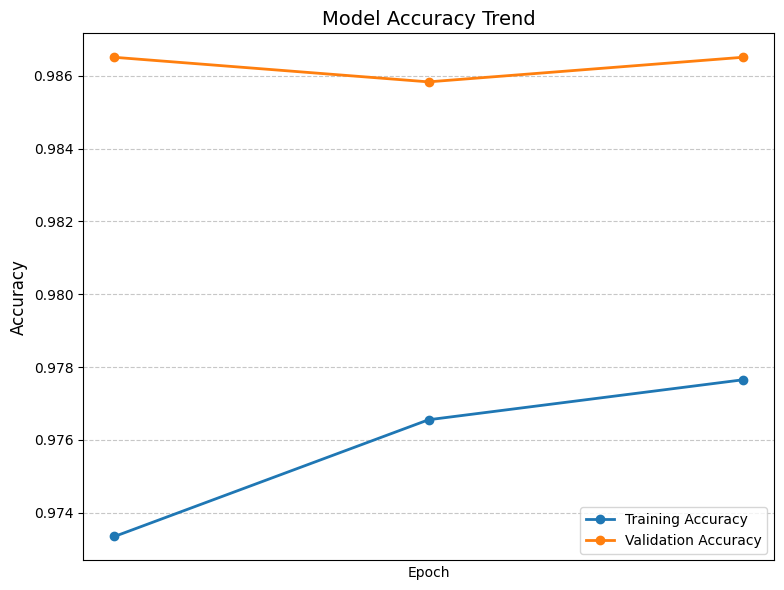

In [42]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(15, 6))

# --- PLOT 1: ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', marker='o', linewidth=2)
plt.title('Model Accuracy Trend', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch')
plt.xticks([])
plt.legend(loc='lower right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7) # Grid hanya horizontal
plt.tight_layout()
plt.show()


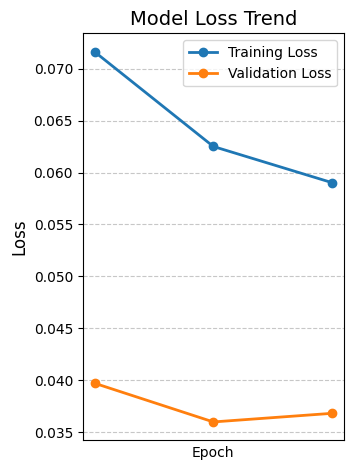

In [43]:
# --- PLOT 2: LOSS ---
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', marker='o', linewidth=2)
plt.plot(val_loss, label='Validation Loss', marker='o', linewidth=2)
plt.title('Model Loss Trend', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch')
plt.xticks([])
plt.legend(loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7) # Grid hanya horizontal

plt.tight_layout()
plt.show()

In [44]:
import tensorflow as tf
model = tf.keras.models.load_model("best_model.h5")


In [45]:
# Export ke SavedModel (Keras 3)
saved_dir = "/content/submission/saved_model"
model.export(saved_dir)  # format SavedModel resmi

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132555936962256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947846672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947842640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947845712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947848016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947832080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968611408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968610832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968611216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968609296: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [47]:
import tensorflow as tf
import os

tflite_dir = "/content/submission/tflite"
os.makedirs(tflite_dir, exist_ok=True)

# Convert ke tflite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save .tflite
with open(f"{tflite_dir}/model.tflite", "wb") as f:
    f.write(tflite_model)

# Save labels
labels = ["Anjing", "Kucing", "Labalaba"]
with open(f"{tflite_dir}/label.txt", "w") as f:
    f.write("\n".join(labels))

print("TFLite + label.txt berhasil dibuat!")


Saved artifact at '/tmp/tmptsq4i60z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132555936962256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947846672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947842640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947845712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947848016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550947832080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968611408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968610832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968611216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550968609296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1325509686079

In [48]:
!pip install tensorflowjs


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.11.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.38.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.4.4 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [49]:
import os

tfjs_dir = "/content/submission/tfjs_model"
os.makedirs(tfjs_dir, exist_ok=True)

!tensorflowjs_converter \
    --input_format=keras \
    /content/best_model.h5 \
    /content/submission/tfjs_model

print("TFJS model berhasil dibuat!")


2025-11-25 15:50:10.101322: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764085810.290156   15333 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764085810.348287   15333 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764085810.498540   15333 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764085810.506096   15333 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764085810.506126   15333 computation_placer.cc:177] computation placer alr

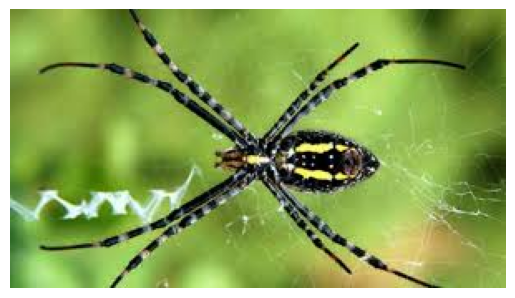

In [50]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = '/content/test1.jpeg'
img = mpimg.imread(img_path)  # baca gambar
plt.imshow(img)
plt.axis('off')  # hilangkan sumbu
plt.show()


In [53]:
import tensorflow as tf
import numpy as np
from PIL import Image

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/content/submission/tflite/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Preprocess image function
def preprocess(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img = np.array(img, dtype=np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    return img

# Inference
img = preprocess("/content/test1.jpeg")   # ganti gambar kamu
interpreter.set_tensor(input_details[0]['index'], img)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

# Mapping label
labels = ["Anjing", "Kucing", "Labalaba"]
pred = labels[np.argmax(output)]
conf = np.max(output)

print("Prediksi:", pred)
print("Confidence:", conf)


Prediksi: Labalaba
Confidence: 1.0


In [57]:
!pip install pipreqsnb

  Preparing metadata (setup.py) ... done
  Created wheel for pipreqsnb: filename=pipreqsnb-0.2.4-py3-none-any.whl size=4128 sha256=6734f6821f328f635d4b3e1d433f600f1bc52099303b3723224a8a7e16ed8b2e
  Stored in directory: /root/.cache/pip/wheels/a6/f6/b8/5bd85cc669a8f4985ea596345127d33cf3569b037cf7e1194d
Successfully built pipreqsnb


In [64]:
!pipreqs --scan-notebooks

Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in /content/requirements.txt
